In [2]:
from pathlib import Path

import pandas as pd


file_name = '0000_5.02'
result_path = Path('/Users/yangyu/PycharmProjects/DeepNav/DeepNav_results')

def read_nn_output(file_path:Path):
    nn_output_path = file_path.joinpath(f'training/reconstructed/nn_output_csv/{file_name}_nn.csv')
    data = pd.read_csv(str(nn_output_path), index_col=0).to_numpy()
    return data


data = read_nn_output(Path('/Users/yangyu/PycharmProjects/DeepNav/DeepNav_results/trial_001'))

from my_utils.io_utils import get_subfolders
trail_list = get_subfolders('/Users/yangyu/PycharmProjects/DeepNav/DeepNav_results')
data_list = []
for folder in trail_list:
    data = read_nn_output(Path(folder))
    data_list.append(data)

/Users/yangyu/PycharmProjects/DeepNav/my_utils/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best', fontsize=11)


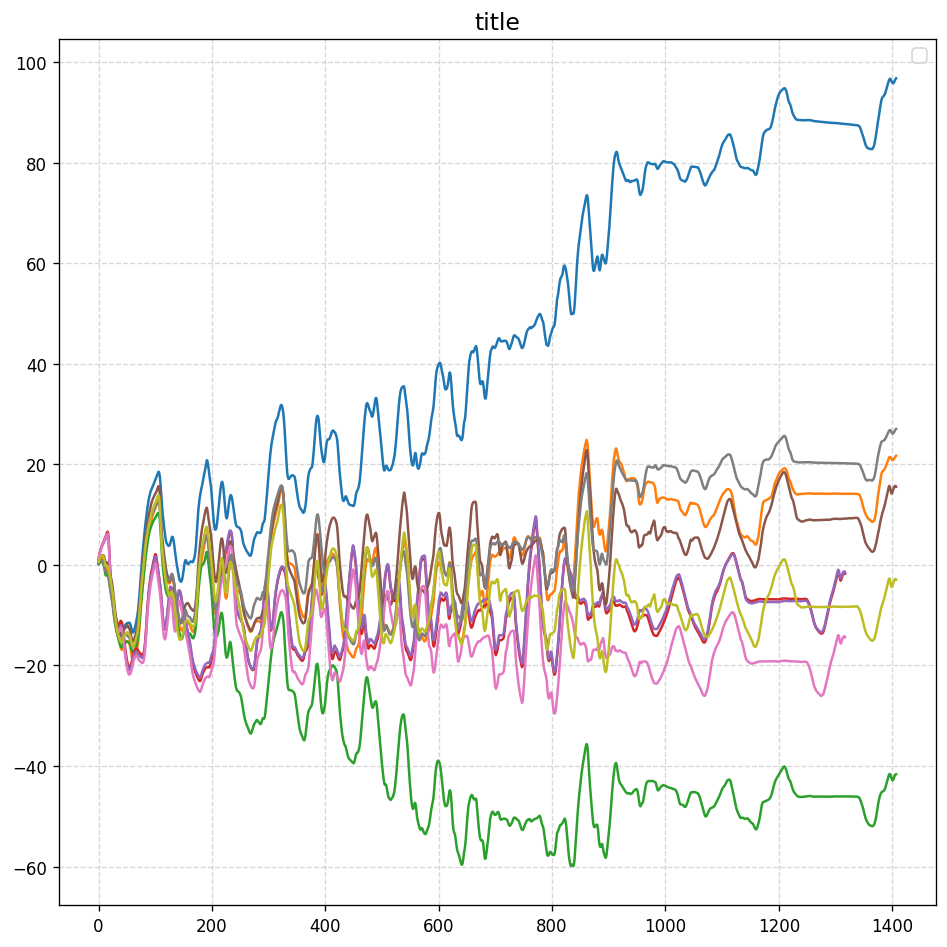

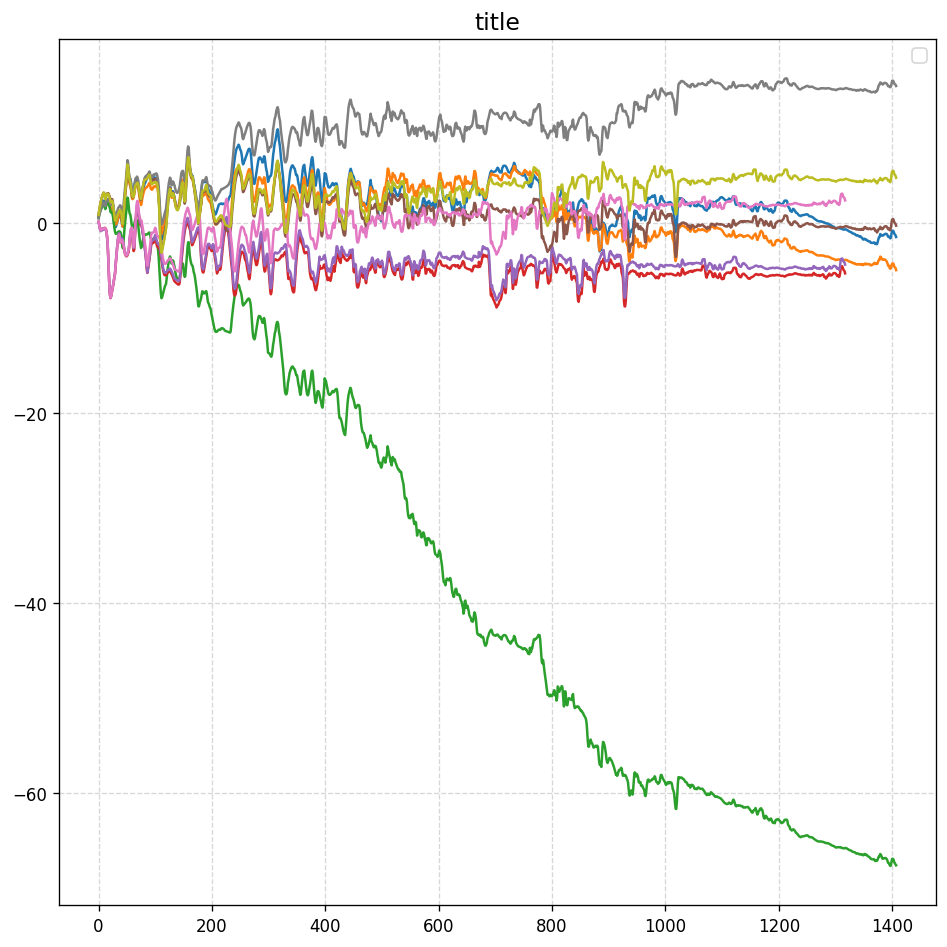

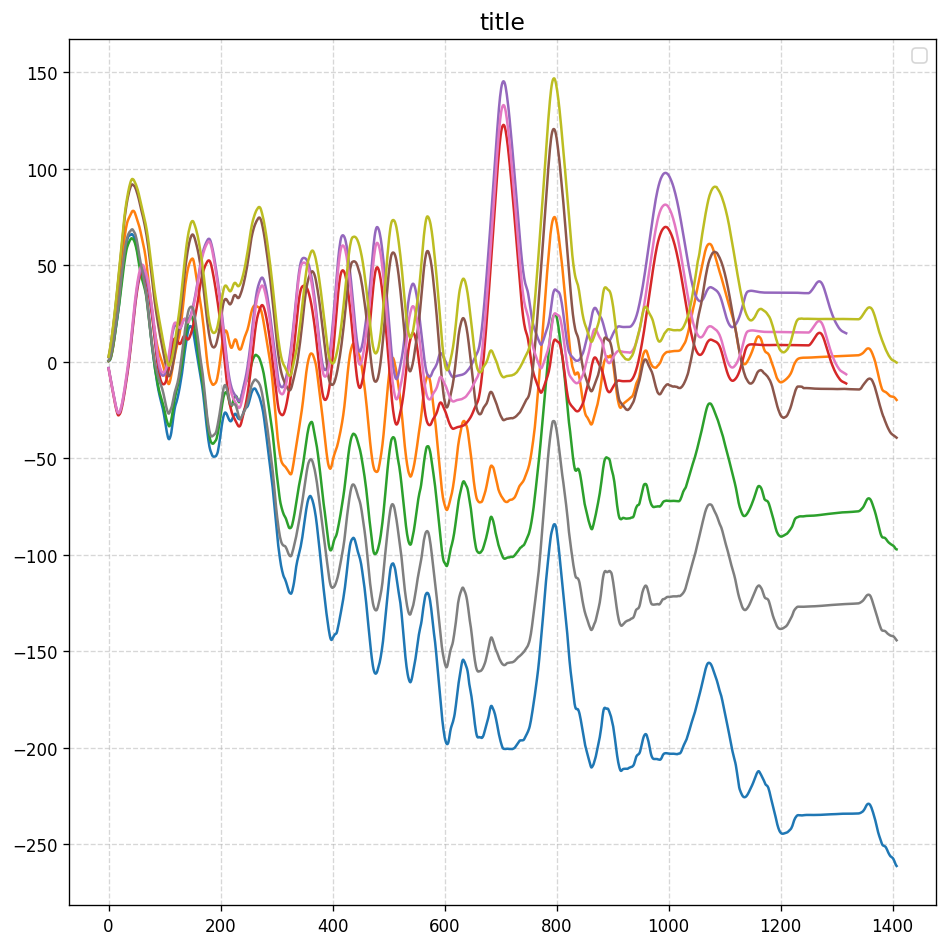

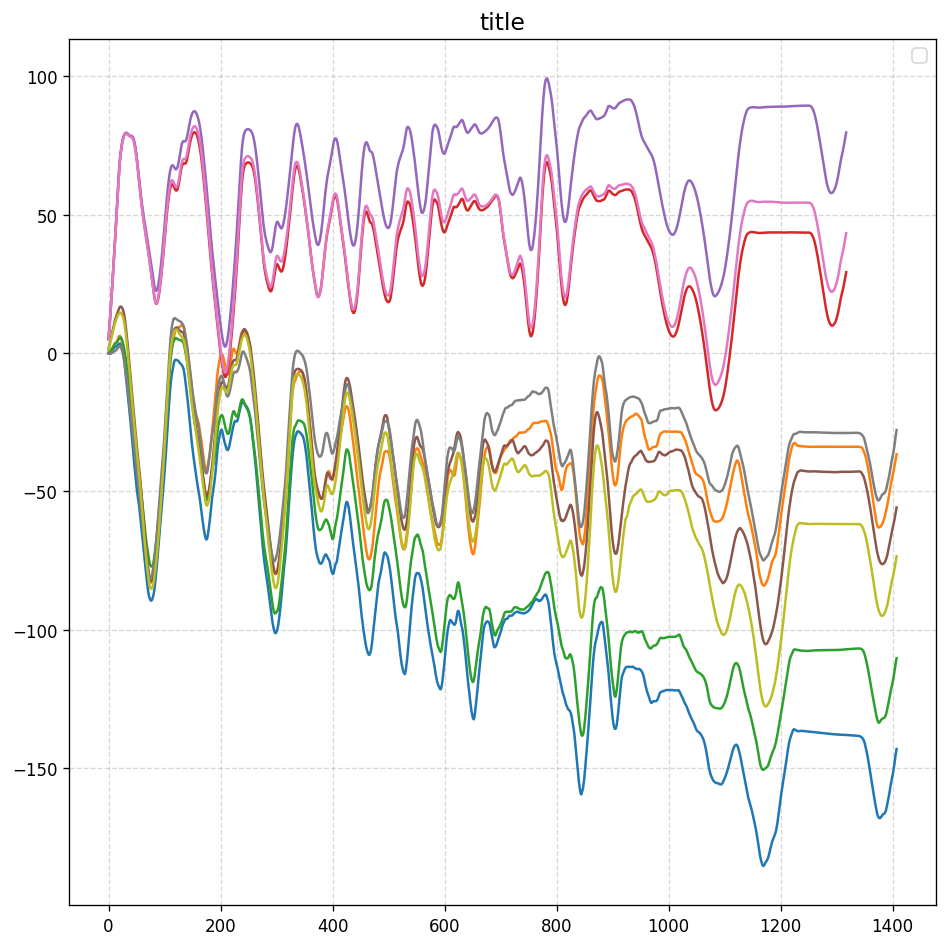

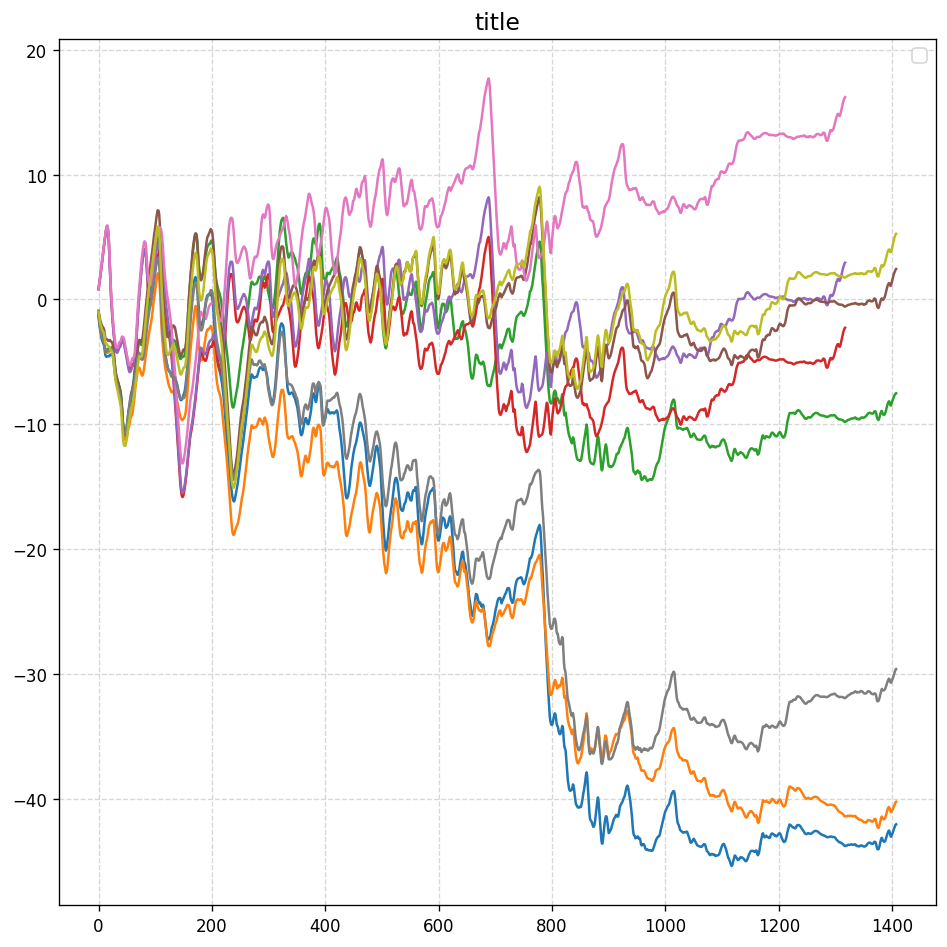

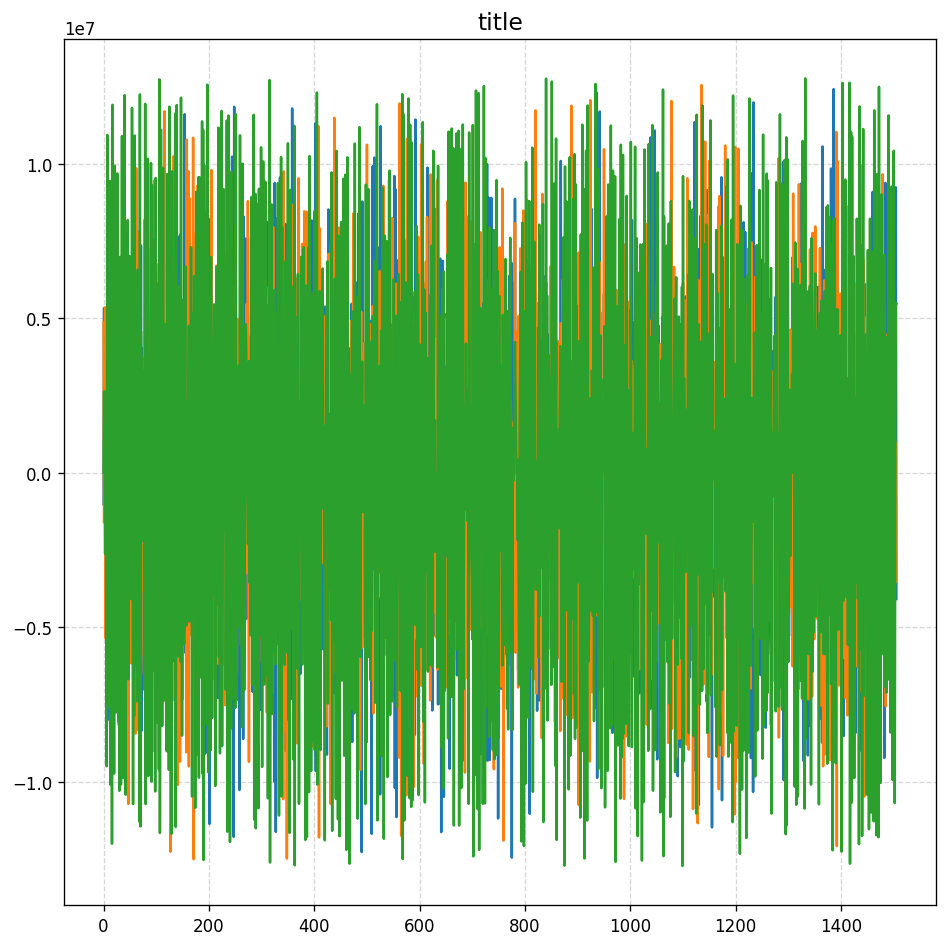

In [3]:
from ekf import geoparams
import importlib
from my_utils import plot_utils
import numpy as np

from ekf.read_data_from_log import read_gps_data
importlib.reload(plot_utils)   # 这里 reload 的是子模块对象
# plot_utils.plot_array_list(data_list)
timestamp, gps_lla, eph, epv, vel_lla = read_gps_data(Path('/Users/yangyu/PycharmProjects/DeepNav/DeepNav_data/flight_csvs/0000_5.02'))
gps_ecef = geoparams.lla2ecef_batch(gps_lla)
gps_data_ref = np.diff(gps_ecef, axis=0)
plot_utils.plot_multidim_lines(gps_data_ref)